# Laboratorio de regresión logística

|                |   |
:----------------|---|
| **Nombre**     | Regina Tamayo León|
| **Fecha**      | 8 mar 2026|
| **Expediente** | 757857|

La regresión logística es una herramienta utilizada para predecir respuestas cualitativas. Al igual que la regresión lineal, es un método sencillo que sirve como un punto de partida para técnicas más avanzadas. Por ejemplo, lo que se conoce como *redes neuronales* o *red de perceptrones multicapa* no es más que una estructura de regresiones logísticas que se alimentan entre sí.

1. Descarga el archivo de créditos y carga los datos (Default.csv). Utiliza `pandas`.

In [2]:
import pandas as pd
data=pd.read_csv("Default.csv")

2. Utiliza el comando `obj.head()`, donde `obj` es el nombre que le diste a los datos del archivo.

In [3]:
data.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138950
3,No,No,529.250605,35704.493940
4,No,No,785.655883,38463.495880


El comando head arroja los primeras *n* líneas (por defecto 5) de los datos que están en el DataFrame.

3. Utiliza el comando `obj.describe()`.

In [4]:
data.describe()

,balance,income
count,10000.000000,10000.000000
mean,835.374886,33516.981876
std,483.714985,13336.639563
min,0.000000,771.967729
25%,481.731105,21340.462903
50%,823.636973,34552.644802
75%,1166.308386,43807.729275
max,2654.322576,73554.233500


El comando describe toma las columnas que tienen datos numéricos y saca datos estadísticos comunes:
- *n*
- media
- desviación estándar
- valor mínimo
- primer cuartil
- mediana
- tercer cuartil
- valor máximo

3. Vistos estos datos, ¿qué columnas existen en el DataFrame? ¿Qué tipo de datos contienen?

el DataFrame contiene dos columnas principales: balance e income. Ambas columnas contienen datos numéricos (específicamente de tipo flotante o float). Además, el que existan múltiples puntos decimales en los resultados confirma que se trata de valores continuos que representan montos monetarios.

4. Configura el tipo de dato de las columnas `default` y `student` para cambiarlos a variables categóricas.

`data[columna] = data[columna].astype("category")`

In [7]:
data['default'] = data['default'].astype('category')

data['student'] = data['student'].astype('category')

Imagina que trabajas en un banco y que se te entregan estos datos. Tu objetivo es crear un modelo que ayude a predecir si una persona que solicita un crédito lo va a pagar. Exploremos los datos un poco más antes de crear un modelo.

Veamos primero cómo es la distribución de los valores cuando una persona dejó de pagar y cuando siguió pagando. `Default` es el término utilizado para cuando una persona dejó de pagar.

5. Crea una gráfica de caja para las columnas `income` y `balance`, con los datos agrupados con la columna `default`. Utiliza el comando `obj.boxplot(column=____, by=_____)`

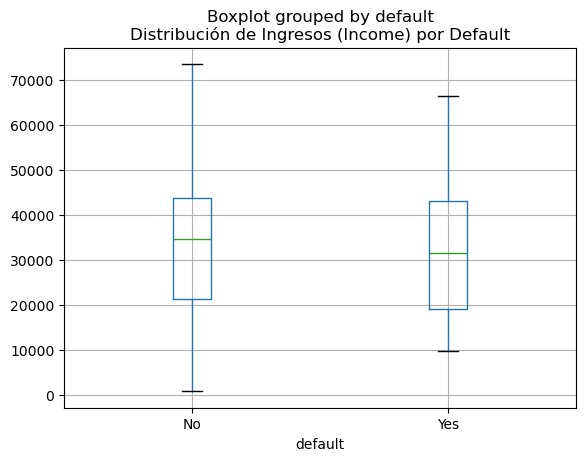

In [8]:
import matplotlib.pyplot as plt
data.boxplot(column='income', by='default')
plt.title('Distribución de Ingresos (Income) por Default')
plt.show()

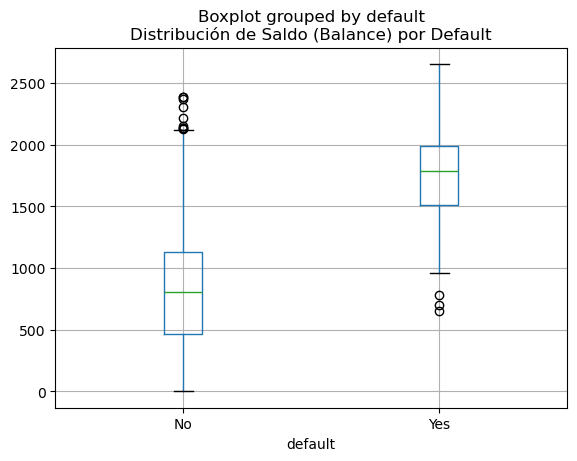

In [9]:
data.boxplot(column='balance', by='default')
plt.title('Distribución de Saldo (Balance) por Default')
plt.show()

6. Crea una gráfica de dispersión donde el eje *x* sea la columna `balance` y el eje *y* la columna `income`. Utiliza el comando `obj.plot.scatter(x, y, c="default", colormap="PiYG_r", alpha=0.5)`.

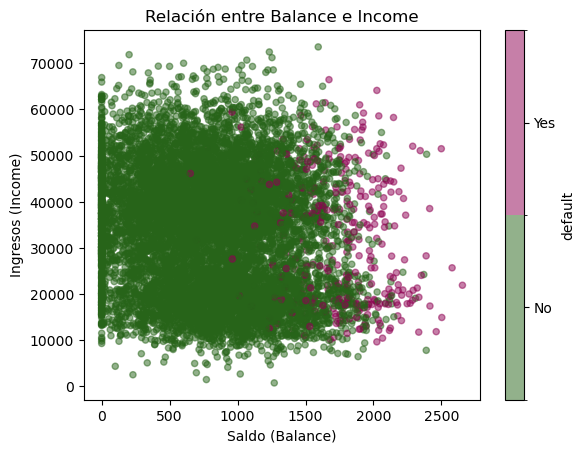

In [10]:
import matplotlib.pyplot as plt

data.plot.scatter(x='balance', y='income', c='default', colormap='PiYG_r', alpha=0.5)

plt.title('Relación entre Balance e Income')
plt.xlabel('Saldo (Balance)')
plt.ylabel('Ingresos (Income)')
plt.show()

La regresión (lineal o logística) se usa para encontrar una línea que ajuste los datos para tomar una decisión. La línea que buscamos en regresión logística es aquella que nos ayude a separar las diferentes categorías. 

<img style="float: left; " src="https://www.baeldung.com/wp-content/uploads/sites/4/2023/10/decision_boundary_curve.jpg" width="400px" />


## Regresión logística simple

Creemos un modelo simple donde sólo utilizamos una de los factores para predecir una respuesta. Quiero conocer la probabilidad de que una persona deje de pagar su crédito dado el balance que tiene en su cuenta.

$$ P(\text{default}=\text{Yes}|\text{balance}) $$

Por el momento la columna default no contiene valores numéricos, por lo que hay que transformar los datos. Como default es nuestra variable de respuesta (lo que queremos predecir) podemos nombrarla *y*.

Ejecuta el código `y = obj["default"] == "Yes"`. Extrae el factor `balance` en una variable *x*.

In [11]:
y = data["default"] == "Yes"
X = data[["balance"]]

Crea un gráfico de dispersión donde el eje *x* sea `balance` y el eje *y* sea `default` transformado.

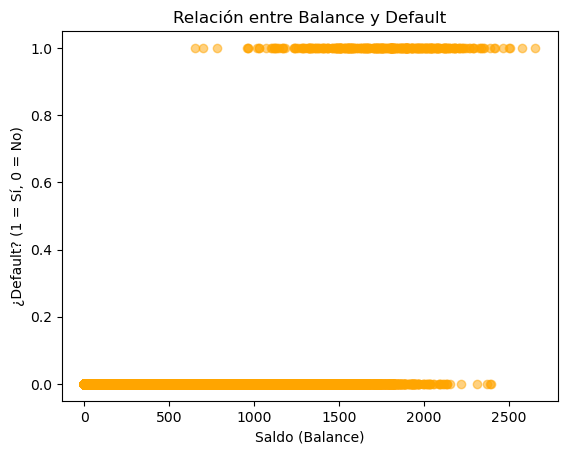

In [14]:
plt.scatter(X, y, alpha=0.5, color='orange')
plt.title('Relación entre Balance y Default')
plt.xlabel('Saldo (Balance)')
plt.ylabel('¿Default? (1 = Sí, 0 = No)')

plt.show()

La línea que utilizaremos para predecir la probabilidad es:

$$ p(x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x)}} $$

Para nuestro ejemplo de pagos y balance:

$$ P(\text{default}=1|\text{balance}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1  \text{balance})}} $$

Buscamos maximizar la probabilidad de que el modelo tome decisiones correctas. Es decir, que cuando `default` fue verdadero, que la predicción sea 100%, y que cuando `default` fue falso que la predicción sea 0%.

$$ \Pi_{i:y_i=1} p(x_i) \Pi_{i':y_{i'}} (1-p(x_{i'})) $$

La función de costo ya simplificada es la siguiente:

$$ J(\vec{\beta}) = -  \sum_{i=1}^n{[y_i \ln{(\hat{p}(x_i))} + (1-y_i)\ln{(1 - \hat{p}(x_i))}]}$$

Utiliza la clase `LogisticRegression` del módulo `linear_model` de la librería `sklearn` para estimar los parámetros del modelo.

In [15]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

In [16]:
model.fit(data[['balance']], y)


LogisticRegression()

In [17]:
beta_0 = model.intercept_[0]
beta_1 = model.coef_[0][0]

print(f"Intercepto (beta_0): {beta_0}")
print(f"Coeficiente de balance (beta_1): {beta_1}")

Intercepto (beta_0): -10.651328236144847
Coeficiente de balance (beta_1): 0.005498915546890769


Muchos aspectos de la regresión logística son similares a la regresión lineal. Podemos medir la precisión de nuestros estimados calculando sus errores estándar. El objetivo de calcular estos errores es asegurar que hay una relación estadísticamente significativa entre el factor y la variable de respuesta.

Los errores estándar se obtienen con el siguiente procedimiento:

1. Calcula las predicciones utilizando los $\beta_0$ y $\beta_1$ encontrados.

In [22]:
import numpy as np

beta_0 = model.intercept_[0]
beta_1 = model.coef_[0][0]

p = 1 / (1 + np.exp(-(beta_0 + beta_1 * data['balance'])))

2. Idealmente la probabilidad debería ser 100% o 0%. Si alguna predicción no fue absoluta significa que hay incertidumbre. Calcula $p(1-p)$ para todas tus predicciones.

In [24]:
varianza_p = p * (1 - p)

3. Crea una matriz vacía y llena la diagonal con las probabilidades encontradas.

`V = np.diagflat(*p(1-p)*)`

In [25]:
V = np.diagflat(varianza_p)

4. Calcula la matriz de covarianza. (Dado que X es la matriz que contiene todos los factores)

`cov = np.linalg.inv(X.T @ V @ X)`

In [28]:
X = np.column_stack([np.ones(len(data)), data['balance']]) # columna de unos al inicio para el intercepto

cov = np.linalg.inv(X.T @ V @ X)

print("Matriz de Covarianza:")
print(cov)

Matriz de Covarianza:
[[ 1.30442757e-01 -7.81757265e-05]
 [-7.81757265e-05  4.85656561e-08]]


5. Los valores en la diagonal de la matriz de covarianza corresponden a la varianza de los factores. Utiliza los valores de la diagonal para calcular el error estándar.

`se = np.sqrt(np.diag(cov))`

In [29]:
se = np.sqrt(np.diag(cov))
print(f"Error Estándar de beta_0: {se[0]}")
print(f"Error Estándar de beta_1: {se[1]}")

Error Estándar de beta_0: 0.3611685997151183
Error Estándar de beta_1: 0.00022037616946191745


Ahora, revisemos si los estimados de nuestros coeficientes demuestran que hay una relación significativa entre los factores y la respuesta.

Calculamos el estadístico *z*

$$ z_j = \frac{\hat{\beta_j}}{\text{SE}(\hat{\beta_j})} $$

In [31]:
SE = np.sqrt(np.diag(cov))

SE_beta0 = SE[0]
SE_beta1 = SE[1]

In [32]:
z_0 = beta_0 / SE_beta0
z_1 = beta_1 / SE_beta1

print(f"Estadístico z para el Intercepto: {z_0:.4f}")
print(f"Estadístico z para el Balance: {z_1:.4f}")

Estadístico z para el Intercepto: -29.4913
Estadístico z para el Balance: 24.9524


Utilizamos el estadístico *z* para encontrar el *p-value*.

`from scipy.stats import norm`

`p_value = 2 * (1 - norm.cdf(abs(z_statistic)))`

In [33]:
from scipy.stats import norm

p_val_beta0 = 2 * (1 - norm.cdf(abs(z_0)))
p_val_beta1 = 2 * (1 - norm.cdf(abs(z_1)))

print(f"P-value Intercepto: {p_val_beta0:.4e}")
print(f"P-value Balance: {p_val_beta1:.4e}")

P-value Intercepto: 0.0000e+00
P-value Balance: 0.0000e+00


¿Es significativa la relación de los factores con la variable de respuesta?

Si $p < 0.05$: Rechazamos la hipótesis de que el balance no influye. Esto significa que el balance es un factor estadísticamente significativo para predecir si alguien dejará de pagar.

para el banco, el saldo actual es un predictor confiable y crítico para identificar clientes en riesgo de impago.

Repite el procedimiento con el factor `student`. 
1. Transforma el factor de {"Yes", "No"} a {1, 0}.
2. Estima los coeficientes. 
3. Calcula el error estándar de tus estimaciones.
   1. Usa tu modelo para encontrar $\hat{p}(X)$
   2. Calcula el error $p(1-p)$
   3. Calcula la matriz de covarianza
   4. Extrae el error estándar
5. Argumenta si los factores son significativos utilizando el *p-value*.
   1. Utiliza el error estándar para calcular el estadístico *z*
   2. Calcula el *p-value*
   3. ¿Son significativos?


*Transforma el factor de {"Yes", "No"} a {1, 0}.*

In [34]:
X_student = (data["student"] == "Yes").astype(int).values.reshape(-1, 1)
y = (data["default"] == "Yes").astype(int)

*Estimar coeficientes*

In [35]:
from sklearn.linear_model import LogisticRegression

model_student = LogisticRegression()
model_student.fit(X_student, y)

beta_0 = model_student.intercept_[0]
beta_1 = model_student.coef_[0][0]

print(f"B0 (Intercepto): {beta_0}")
print(f"B1 (Coeficiente Student): {beta_1}")

B0 (Intercepto): -3.502572491853133
B1 (Coeficiente Student): 0.3962088847686545


*Errores estándar de estimaciones*

In [ ]:
import numpy as np

p_hat = 1 / (1 + np.exp(-(beta_0 + beta_1 * X_student.flatten())))

In [ ]:
varianza_p = p_hat * (1 - p_hat)
V = np.diagflat(varianza_p)

In [ ]:
X_matriz = np.column_stack([np.ones(len(X_student)), X_student])
cov = np.linalg.inv(X_matriz.T @ V @ X_matriz)

In [ ]:
se = np.sqrt(np.diag(cov))
print(f"SE para B0: {se[0]}")
print(f"SE para B1: {se[1]}")

*Significancia*

In [37]:
from scipy.stats import norm

z_statistic = beta_1 / se[1]

p_value = 2 * (1 - norm.cdf(abs(z_statistic)))

print(f"Estadístico z: {z_statistic}")
print(f"P-value: {p_value}")


Estadístico z: 1797.8753589195233
P-value: 0.0


El hecho de que el p-value sea prácticamente cero significa que existe una relación estadística muy fuerte entre ser estudiante y la probabilidad de entrar en default. No es un resultado producto del azar.

## Regresión logística múltiple

Considera ahora el caso de múltiples factores. Intentemos predecir si la persona dejará de pagar su crédito utilizando toda la información que tenemos disponible. I.e.

$$ P(\text{default}=1|\text{balance}, \text{income}, \text{student}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1  \text{balance} + \beta_2 \text{income} + \beta_3 \text{student})}} $$

1. Utiliza `LogisticRegression` para estimar los coeficientes.
2. Calcula el error estándar de tus estimaciones.
3. Argumenta si los factores son significativos utilizando el *p-value*. 

*Estimar coeficientes*

In [38]:
from sklearn.linear_model import LogisticRegression

data['student_num'] = (data['student'] == 'Yes').astype(int)
X_multiple = data[['balance', 'income', 'student_num']]
y = (data['default'] == 'Yes').astype(int)

model_mult = LogisticRegression()
model_mult.fit(X_multiple, y)

beta_0 = model_mult.intercept_[0]
betas = model_mult.coef_[0] 

print(f"Intercepto (B0): {beta_0}")
print(f"Coeficientes (balance, income, student): {betas}")

Intercepto (B0): -10.90179029123049
Coeficientes (balance, income, student): [ 5.73059547e-03  3.96182755e-06 -6.12573844e-01]


*Error estándar*

In [39]:
import numpy as np

linear_comb = beta_0 + np.dot(X_multiple, betas)
p_hat = 1 / (1 + np.exp(-linear_comb))

v_diag = p_hat * (1 - p_hat)
V = np.diagflat(v_diag)

X_design = np.column_stack([np.ones(len(X_multiple)), X_multiple])
cov_mult = np.linalg.inv(X_design.T @ V @ X_design)

se_mult = np.sqrt(np.diag(cov_mult))
print(f"Errores estándar: {se_mult}")

Errores estándar: [4.93157606e-01 2.31674960e-04 8.20843577e-06 2.36393842e-01]


*Significancia*

In [41]:
from scipy.stats import norm

z_scores = [beta_0/se_mult[0]] + [b/s for b, s in zip(betas, se_mult[1:])]
p_values = [2 * (1 - norm.cdf(abs(z))) for z in z_scores]

factores = ['Intercepto', 'Balance', 'Income', 'Student']
for f, p in zip(factores, p_values):
    significancia = "ES significativo" if p < 0.05 else "NO es significativo"
    print(f"{f}: p-value = {p:.4e} ({significancia})")

Intercepto: p-value = 0.0000e+00 (ES significativo)
Balance: p-value = 0.0000e+00 (ES significativo)
Income: p-value = 6.2934e-01 (NO es significativo)
Student: p-value = 9.5606e-03 (ES significativo)


El banco debería centrar su modelo de riesgo principalmente en el Balance y el estatus de Student. Incluir el Income en este modelo específico podría estar agregando ruido innecesario, ya que no demuestra una relación estadísticamente significativa con la variable de respuesta (default).

¿Cómo sabemos qué tan bueno es el modelo? Hay cuatro posibles casos para un problema de clasificación simple:
- Era sí y se predijo sí. (Verdadero positivo **TP**)
- Era sí y se predijo no. (Falso negativo **FN**)
- Era no y se predijo sí. (Falso positivo **FP**)
- Era no y se predijo no. (Verdadero negativo **TN**)

De esos cuatro casos hay dos donde el modelo es correcto y dos donde el modelo no es correcto.

![](https://miro.medium.com/v2/resize:fit:720/format:webp/1*IuymDnZpRlkat0qejE26Nw.png)

1. Menciona dos ejemplos donde consideres que un falso positivo sea un peor resultado que un falso negativo.

Un examen médico de rutina le dice a un atleta olímpico que es alérgico al gluten por error. El atleta deja de comer carbohidratos y pierde toda su energía para la competencia. El error de diagnóstico le costó la medalla.

Un médico receta antibióticos fuertes a un paciente que solo tiene un virus común . El paciente desarrolla resistencia a los medicamentos y efectos secundarios sin necesidad. La acción fue más dañina que la enfermedad.

2. Menciona dos ejemplos donde consideres que un falso negativo sea un peor resultado que un falso positivo.

Un sensor en una planta purificadora indica que el agua no tiene bacterias cuando en realidad está contaminada. La gente bebe el agua pensando que está limpia y se enferma. No ver la bacteria es mucho más grave que dar una falsa alarma de limpieza.

## Referencia

James, G., Witten, D., Hastie, T., Tibshirani, R.,, Taylor, J. (2023). An Introduction to Statistical Learning with Applications in Python. Cham: Springer. ISBN: 978-3-031-38746-3